# Comparação de Segmentos de Mercado
## Dataset completo vs. Segmento p5–p95

Compara o desempenho dos modelos (OLS, Random Forest, XGBoost) em dois recortes:
- **Completo:** todas as observações
- **Segmento:** p5–p95 do valor (exclui ~10% dos extremos)

**Objetivo:** verificar se os modelos performam melhor no mercado intermediário.

---
## Imports e configurações

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':        'Arial',
    'font.size':          10,
    'axes.labelsize':     11,
    'axes.labelcolor':    'black',
    'axes.titlesize':     0,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.linewidth':     1.5,
    'axes.edgecolor':     'black',
    'xtick.color':        'black',
    'ytick.color':        'black',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'axes.grid':          False,
    'axes.facecolor':     'white',
    'figure.facecolor':   'white',
    'figure.dpi':         120,
})

COR      = '#4878CF'
COR_CINZA = '#95a5a6'
SEED     = 42

def aplicar_estilo(ax):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    ax.set_title('')
    ax.tick_params(colors='black')

print('OK')

OK


## Configurações de caminho e funções auxiliares

In [5]:
ENTRADA   = 'imoveis_sanitizado.csv'
SAIDA_DIR = 'ml_output'
os.makedirs(SAIDA_DIR, exist_ok=True)

NUMERICAS  = ['tamanho_m2', 'quartos', 'banheiros', 'vagas', 'valor']
AMENIDADES = ['piscina', 'sacada', 'churrasqueira',
              'elevador', 'academia', 'salao_de_festas']
# imovel_mobiliado excluído — removido pelo stepwise (p=0,054)

def metricas(y_true_log, y_pred_log):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    return {
        'R2':     round(r2_score(y_true, y_pred), 4),
        'RMSE':   round(np.sqrt(mean_squared_error(y_true, y_pred)), 0),
        'MAE':    round(mean_absolute_error(y_true, y_pred), 0),
        'MAPE':   round(np.mean(np.abs((y_true - y_pred) / y_true)) * 100, 2),
        'R2_log': round(r2_score(y_true_log, y_pred_log), 4),
    }

def preparar(df_input):
    df = df_input.copy()
    df['log_valor']      = np.log(df['valor'])
    df['log_tamanho_m2'] = np.log(df['tamanho_m2'])
    df_m = pd.get_dummies(df, columns=['regiao', 'tipo'], drop_first=True)
    subs = str.maketrans('ãõçéêáâóôúí', 'aoceeaaooui')
    df_m.columns = [
        c.translate(subs).replace(' ', '_')
         .replace('[', '').replace(']', '')
         .replace('(', '').replace(')', '')
        for c in df_m.columns
    ]
    for col in df_m.columns:
        if df_m[col].dtype == bool:
            df_m[col] = df_m[col].astype('int8')
    dummies  = [c for c in df_m.columns
                if c.startswith('regiao_') or c.startswith('tipo_')]
    features = (['log_tamanho_m2', 'quartos', 'banheiros', 'vagas']
                + AMENIDADES + dummies)
    X = df_m[features].astype('float64')
    y = df_m['log_valor'].astype('float64')
    return X, y, features

def treinar_avaliar(X_train, X_test, y_train, y_test, cv):
    resultados = {}

    # OLS
    ols = LinearRegression().fit(X_train, y_train)
    resultados['OLS'] = metricas(y_test, ols.predict(X_test))

    # Random Forest
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        param_distributions={
            'n_estimators':      [100, 200, 300, 500],
            'max_depth':         [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf':  [1, 2, 4],
            'max_features':      ['sqrt', 'log2', 0.5],
        },
        n_iter=40, cv=cv, scoring='neg_root_mean_squared_error',
        random_state=SEED, n_jobs=-1, verbose=0,
    )
    rf_search.fit(X_train, y_train)
    resultados['Random Forest'] = metricas(y_test, rf_search.best_estimator_.predict(X_test))
    resultados['RF_params']     = rf_search.best_params_

    # XGBoost
    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=SEED, n_jobs=-1,
                     tree_method='hist', verbosity=0),
        param_distributions={
            'n_estimators':     [100, 200, 300, 500],
            'max_depth':        [3, 4, 5, 6, 8],
            'learning_rate':    [0.01, 0.05, 0.1, 0.2],
            'subsample':        [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'min_child_weight': [1, 3, 5],
            'gamma':            [0, 0.1, 0.3],
        },
        n_iter=40, cv=cv, scoring='neg_root_mean_squared_error',
        random_state=SEED, n_jobs=-1, verbose=0,
    )
    xgb_search.fit(X_train, y_train)
    resultados['XGBoost']    = metricas(y_test, xgb_search.best_estimator_.predict(X_test))
    resultados['XGB_params'] = xgb_search.best_params_

    return resultados

print(f'Saída em: {os.path.abspath(SAIDA_DIR)}')

Saída em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\ml_output


---
## Carregamento e definição dos recortes

In [6]:
df_raw = pd.read_csv(ENTRADA, encoding='utf-8-sig', low_memory=False)
df_raw[NUMERICAS]  = df_raw[NUMERICAS].apply(pd.to_numeric, errors='coerce')
df_raw[AMENIDADES] = df_raw[AMENIDADES].fillna(0).astype(int)
df_raw             = df_raw[NUMERICAS + AMENIDADES + ['regiao', 'tipo']].dropna()

p5  = df_raw['valor'].quantile(0.05)
p95 = df_raw['valor'].quantile(0.95)

df_completo = df_raw.copy()
df_segmento = df_raw[
    (df_raw['valor'] >= p5) & (df_raw['valor'] <= p95)
].copy()

print('RECORTES DO DATASET')
print('=' * 50)
print(f"  Completo:  {len(df_completo):,} obs  |  R${df_completo['valor'].min():,.0f} – R${df_completo['valor'].max():,.0f}")
print(f"  Segmento:  {len(df_segmento):,} obs  |  R${p5:,.0f} – R${p95:,.0f}  (p5–p95)")
print(f"  Excluídos: {len(df_completo)-len(df_segmento):,} obs ({100*(len(df_completo)-len(df_segmento))/len(df_completo):.1f}%)")

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

RECORTES DO DATASET
  Completo:  8,056 obs  |  R$90,000 – R$50,000,000
  Segmento:  7,268 obs  |  R$350,000 – R$4,712,500  (p5–p95)
  Excluídos: 788 obs (9.8%)


---
## Recorte 1 — Dataset completo
⏳ Pode levar alguns minutos.

In [7]:
X_c, y_c, feats_c = preparar(df_completo)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c, y_c, test_size=0.2, random_state=SEED)

print(f'Treino: {len(X_c_tr):,}  |  Teste: {len(X_c_te):,}')
print('Treinando...')
res_completo = treinar_avaliar(X_c_tr, X_c_te, y_c_tr, y_c_te, cv)
print('Concluído.')
for m in ['OLS', 'Random Forest', 'XGBoost']:
    print(f"  {m:<16} R²={res_completo[m]['R2']:.4f}  MAPE={res_completo[m]['MAPE']:.2f}%")

Treino: 6,444  |  Teste: 1,612
Treinando...
Concluído.
  OLS              R²=0.7168  MAPE=29.17%
  Random Forest    R²=0.7339  MAPE=25.69%
  XGBoost          R²=0.7419  MAPE=26.27%


---
## Recorte 2 — Segmento p5–p95
⏳ Pode levar alguns minutos.

In [8]:
X_s, y_s, feats_s = preparar(df_segmento)
X_s_tr, X_s_te, y_s_tr, y_s_te = train_test_split(
    X_s, y_s, test_size=0.2, random_state=SEED)

print(f'Treino: {len(X_s_tr):,}  |  Teste: {len(X_s_te):,}')
print('Treinando...')
res_segmento = treinar_avaliar(X_s_tr, X_s_te, y_s_tr, y_s_te, cv)
print('Concluído.')
for m in ['OLS', 'Random Forest', 'XGBoost']:
    print(f"  {m:<16} R²={res_segmento[m]['R2']:.4f}  MAPE={res_segmento[m]['MAPE']:.2f}%")

Treino: 5,814  |  Teste: 1,454
Treinando...
Concluído.
  OLS              R²=0.5809  MAPE=27.27%
  Random Forest    R²=0.7165  MAPE=23.78%
  XGBoost          R²=0.7213  MAPE=23.69%


---
## Comparação: Completo vs Segmento p5–p95

In [9]:
modelos = ['OLS', 'Random Forest', 'XGBoost']
linhas  = []
for m in modelos:
    for recorte, res in [('Completo', res_completo), ('Segmento p5-p95', res_segmento)]:
        linha = {'Modelo': m, 'Recorte': recorte}
        linha.update(res[m])
        linhas.append(linha)

tabela = pd.DataFrame(linhas)
tabela.to_csv(os.path.join(SAIDA_DIR, 'comparacao_segmentos.csv'),
              index=False, encoding='utf-8-sig')

print('Ganho do segmento p5–p95 sobre o completo:')
print(f"  {'Modelo':<16} {'ΔR²':>8}  {'ΔRMSE (R$)':>14}  {'ΔMAPE (pp)':>12}")
print('  ' + '─' * 55)
for m in modelos:
    r_c = res_completo[m]
    r_s = res_segmento[m]
    print(f"  {m:<16} {r_s['R2']-r_c['R2']:>+8.4f}  "
          f"R${r_s['RMSE']-r_c['RMSE']:>+11,.0f}  "
          f"{r_s['MAPE']-r_c['MAPE']:>+11.2f}pp")

tabela

Ganho do segmento p5–p95 sobre o completo:
  Modelo                ΔR²      ΔRMSE (R$)    ΔMAPE (pp)
  ───────────────────────────────────────────────────────
  OLS               -0.1359  R$   -370,490        -1.90pp
  Random Forest     -0.0174  R$   -447,300        -1.91pp
  XGBoost           -0.0206  R$   -437,319        -2.58pp


,Modelo,Recorte,R2,RMSE,MAE,MAPE,R2_log
0,OLS,Completo,0.7168,971153.0,504628.0,29.17,0.7910
1,OLS,Segmento p5-p95,0.5809,600663.0,372058.0,27.27,0.7118
2,Random Forest,Completo,0.7339,941302.0,457138.0,25.69,0.8186
3,Random Forest,Segmento p5-p95,0.7165,494002.0,321394.0,23.78,0.7663
4,XGBoost,Completo,0.7419,927113.0,462804.0,26.27,0.8183
5,XGBoost,Segmento p5-p95,0.7213,489794.0,318692.0,23.69,0.7716


## Gráfico de comparação de métricas

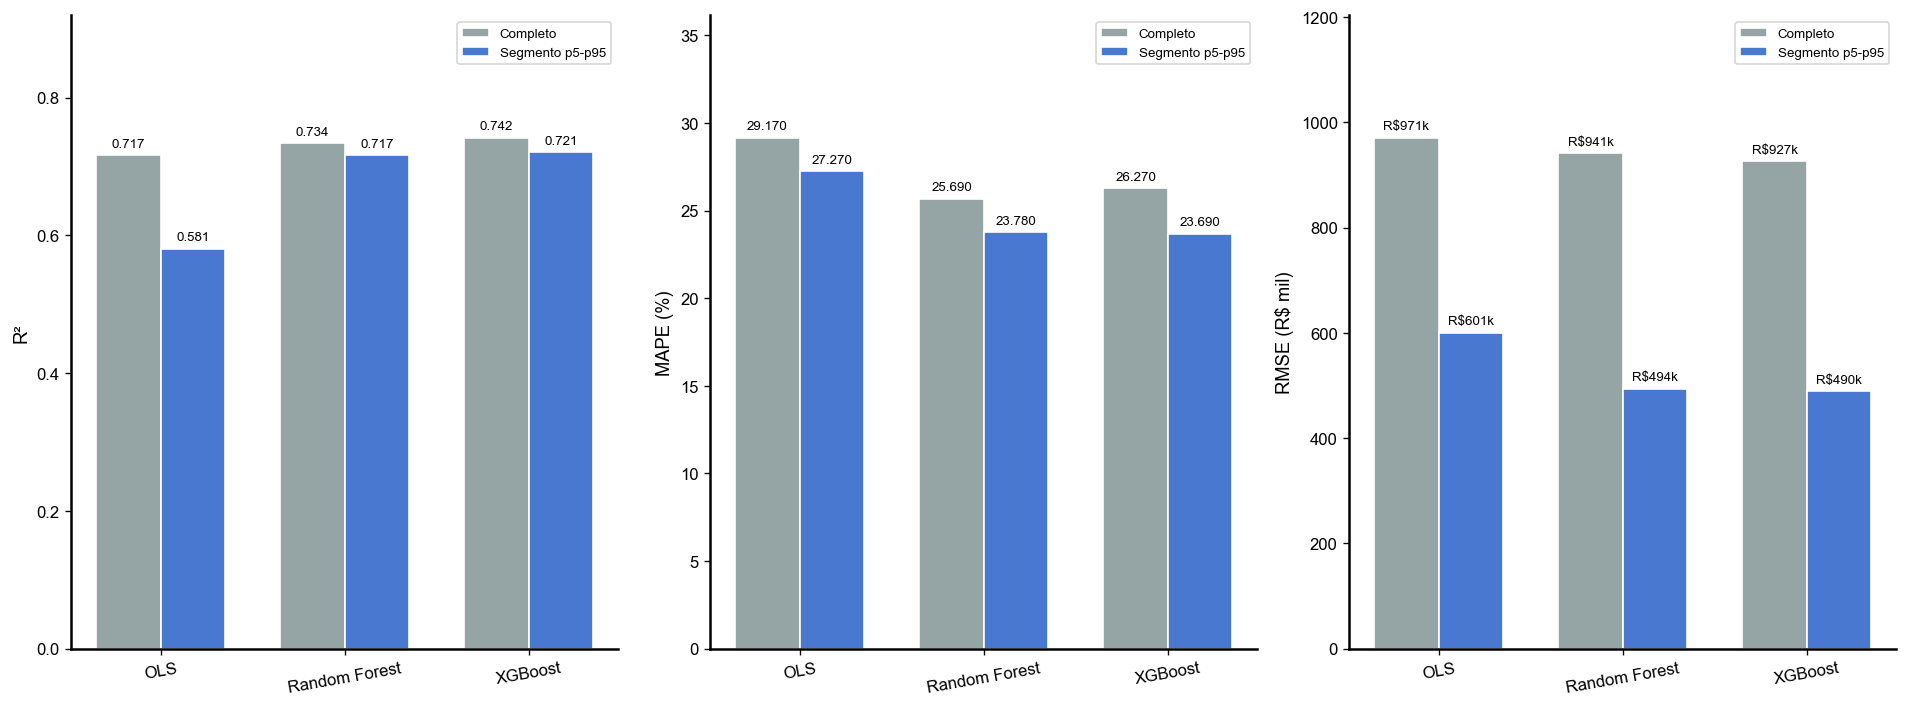

In [10]:
x       = np.arange(len(modelos))
largura = 0.35
cores_recorte = {'Completo': COR_CINZA, 'Segmento p5-p95': COR}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metricas_plot = [
    ('R2',   'R²',        None),
    ('MAPE', 'MAPE (%)',  None),
    ('RMSE', 'RMSE (R$ mil)', 1000),
]

for ax, (met, ylabel, divisor) in zip(axes, metricas_plot):
    for i, (recorte, res) in enumerate([('Completo',       res_completo),
                                         ('Segmento p5-p95', res_segmento)]):
        vals = [res[m][met] / (divisor or 1) for m in modelos]
        bars = ax.bar(x + i * largura, vals, largura,
                      label=recorte,
                      color=cores_recorte[recorte],
                      edgecolor='white')
        ax.bar_label(bars,
                     labels=[f'{v:.3f}' if not divisor else f'R${v:.0f}k'
                             for v in vals],
                     padding=3, fontsize=8)
    ax.set_xticks(x + largura / 2)
    ax.set_xticklabels(modelos, rotation=10)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    ax.legend(fontsize=8)
    aplicar_estilo(ax)

plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'comparacao_segmentos.png'), bbox_inches='tight', dpi=150)
plt.show()

## Gráfico de distribuição dos recortes

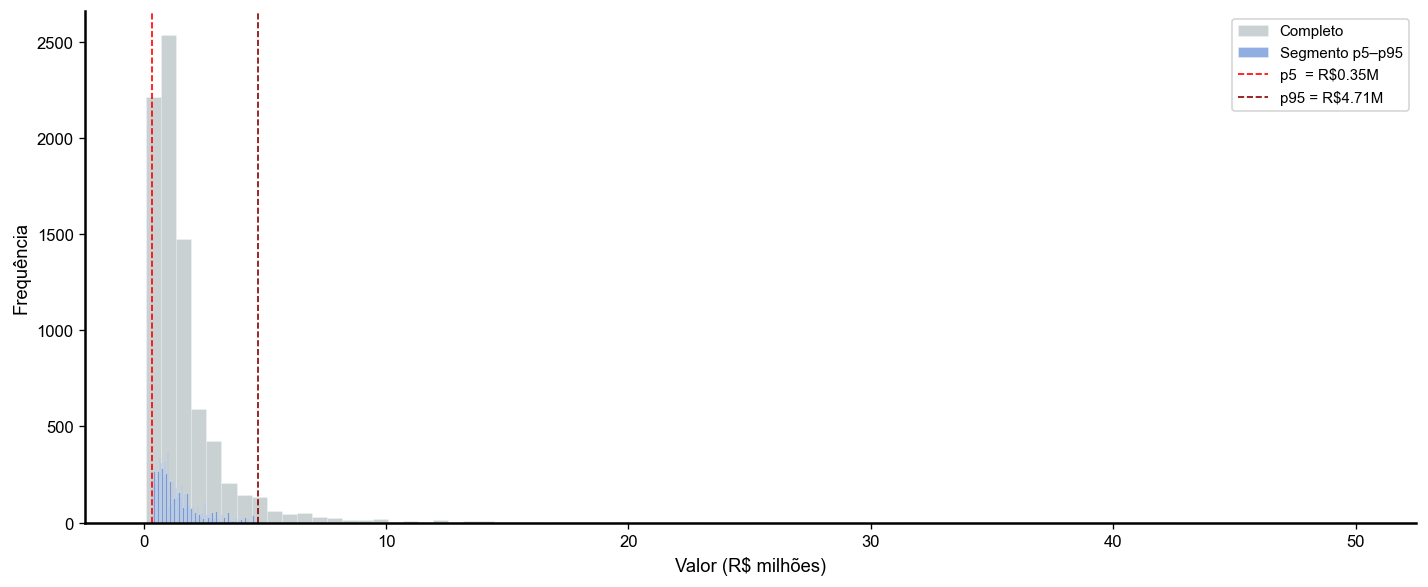

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_completo['valor'] / 1e6, bins=80, alpha=0.5,
        color=COR_CINZA, label='Completo',
        edgecolor='white', linewidth=0.3)
ax.hist(df_segmento['valor'] / 1e6, bins=80, alpha=0.6,
        color=COR, label='Segmento p5–p95',
        edgecolor='white', linewidth=0.3)
ax.axvline(p5  / 1e6, color='red',     linestyle='--', linewidth=1,
           label=f'p5  = R${p5/1e6:.2f}M')
ax.axvline(p95 / 1e6, color='darkred', linestyle='--', linewidth=1,
           label=f'p95 = R${p95/1e6:.2f}M')

ax.set_xlabel('Valor (R$ milhões)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)
aplicar_estilo(ax)

plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'distribuicao_recortes.png'), bbox_inches='tight', dpi=150)
plt.show()

## Hiperparâmetros selecionados por recorte

In [12]:
for recorte, res in [('Completo', res_completo), ('Segmento p5-p95', res_segmento)]:
    print(f'\n{recorte}:')
    print(f"  Random Forest: {res['RF_params']}")
    print(f"  XGBoost:       {res['XGB_params']}")


Completo:
  Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30}
  XGBoost:       {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

Segmento p5-p95:
  Random Forest: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30}
  XGBoost:       {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


---
## Relatório final

In [13]:
print('CONCLUÍDO')
print('=' * 50)
print(f'  Completo:  {len(df_completo):,} obs')
print(f'  Segmento:  {len(df_segmento):,} obs  (R${p5:,.0f} – R${p95:,.0f})')
print(f'\n  Arquivos em: {os.path.abspath(SAIDA_DIR)}')
for arq in sorted(os.listdir(SAIDA_DIR)):
    if any(x in arq for x in ['segment', 'recorte', 'distribuicao', 'comparacao']):
        print(f'    {arq}')

CONCLUÍDO
  Completo:  8,056 obs
  Segmento:  7,268 obs  (R$350,000 – R$4,712,500)

  Arquivos em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\ml_output
    comparacao_modelos.csv
    comparacao_modelos.png
    comparacao_segmentos.csv
    comparacao_segmentos.png
    distribuicao_recortes.png
